In [1]:
# (1) Apply RTL CSS for Persian notebooks
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل 7 — ماشین‌های بردار پشتیبان (SVM)
## درس 9: برآورد احتمال در SVM و ملاحظات کالیبراسیون

در این درس یاد می‌گیرید **چگونه (و چرا) امتیازهای مارجینِ SVM را به احتمال‌های خوب‌کالیبره تبدیل کنید**، چگونه **بدکالیبراسیونی** را تشخیص دهید، و چگونه **بدون نشت داده (data leakage)** کالیبراسیون را به‌درستی انجام دهید.

ما از چند دیتاست مختلف داخل همین ریپازیتوری استفاده می‌کنیم (با مسیرهای نسبی مثل `../../../Datasets/...`):

- `diabetes.csv` (طبقه‌بندی دودویی با ویژگی‌های عددی)
- `iris.csv` (طبقه‌بندی چندکلاسه با ویژگی‌های عددی)
- `glass.csv` (طبقه‌بندی چندکلاسه با ویژگی‌های عددی)
- `drug200.csv` (طبقه‌بندی با ویژگی‌های دسته‌ای + عددی؛ برای نمایش پایپلاین‌های پیش‌پردازش)
- `Wine_Quality.csv` (یک برچسب **دودویی** می‌سازیم: کیفیت بالا در برابر غیرِآن)

> **نکته مهم:** SVM ذاتاً یک مدل **مارجین‌محور** است. امتیاز مارجین به‌خودی‌خود «احتمال» نیست.

### اهداف یادگیری

در پایان این نوت‌بوک باید بتوانید:

1. توضیح دهید چرا تابع تصمیم SVM یعنی $f(x)$ یک احتمال $P(y=1\mid x)$ نیست.
2. **Platt scaling** (نگاشت سیگموید) را مشتق و تفسیر کنید و فرض‌های آن را بشناسید.
3. مفهوم **کالیبراسیون با رگرسیون ایزوتونیک** و مصالحهٔ بایاس–واریانس آن را درک کنید.
4. ابزارهای `sklearn` (`SVC(probability=True)`، `CalibratedClassifierCV`، `CalibrationDisplay`، `calibration_curve`) را درست و بدون خطا به‌کار بگیرید.
5. کیفیت احتمال را با **log loss**، **Brier score**، **نمودار اطمینان/کالیبراسیون** و خلاصه‌های نوع ECE ارزیابی کنید.
6. از خطاهای رایج جلوگیری کنید: **نشت داده**، تنظیم غیرتودرتو، کالیبره‌کردن روی تست، و کالیبراسیون تحت تغییر توزیع.
7. درک شهودی از ساخت احتمال‌های چندکلاسه (OvR / OvO و ایدهٔ **pairwise coupling**) داشته باشید.

### پیش‌نیازها و نمادگذاری

فرض می‌کنیم فرمول‌بندی استاندارد SVM را از درس‌های قبلی می‌دانید:

- برچسب‌های دودویی $y_i \in \{-1,+1\}$
- نگاشت ویژگی $\phi(x)$ که توسط کرنل $K(x,x') = \langle \phi(x), \phi(x') \rangle$ القا می‌شود
- تابع تصمیم (دودویی):
  $$ f(x) = w^\top \phi(x) + b $$
  و پیش‌بینی $\hat{y}(x) = \mathrm{sign}(f(x))$.
- SVM با حاشیهٔ نرم (مسئلهٔ پرایمال):
  $$
  \min_{w,b,\xi} \ \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \xi_i
  \quad \text{s.t.} \quad y_i(w^\top \phi(x_i) + b) \ge 1 - \xi_i,\ \xi_i \ge 0.
  $$

ایدهٔ کلیدی: **$f(x)$ یک مارجین (کمیتی شبیه فاصلهٔ علامت‌دار) در فضای ویژگی است، نه یک احتمال کالیبره**.

در ادامه می‌نویسیم:
- $s(x) := f(x)$ به‌عنوان امتیاز SVM (تابع تصمیم / مارجین)
- $\hat{p}(x)$ به‌عنوان احتمال تخمینی (پس از کالیبراسیون)

## 1) چرا کالیبراسیون احتمال مهم است (و چه زمانی به آن نیاز داریم)

بسیاری از زنجیره‌های تصمیم‌گیری به «احتمال» نیاز دارند نه صرفاً برچسب:

- **تصمیم‌گیری ریسک/هزینه‌محور**: انتخاب عمل $a$ که امیدِ زیان را کمینه کند:
  $$ a^\star(x) = \arg\min_a \sum_{y} L(a,y)\,P(y\mid x). $$
- **انتخاب آستانه**: در دودویی، آستانه $t$ روی احتمال تعریف می‌شود:
  $$ \hat{y}(x) = \mathbb{1}\{\hat{p}(x) \ge t\}. $$
  اگر $\hat{p}(x)$ بدکالیبره باشد، آستانه‌گذاری ناپایدار می‌شود.
- **رتبه‌بندی در برابر احتمال**: ممکن است AUC بالا باشد ولی احتمال‌ها غلط باشند.
- **به‌روزرسانی‌های بیزی** و **انسمبل‌ها** اغلب معنای احتمال را فرض می‌کنند.
- **انسان در حلقه**: وقتی مدل می‌گوید «80% مطمئنم»، انتظار دارید واقعاً نزدیک به 80% درست باشد.

### کالیبراسیون در برابر تمایزبخشی (discrimination)

دو کیفیت متفاوت:

- **Discrimination**: توانایی جداسازی کلاس‌ها (رتبه‌بندی). معیارها: AUC، accuracy.
- **Calibration**: تطابق احتمال پیش‌بینی‌شده با فراوانی واقعی. معیارها: log loss، Brier، نمودار کالیبراسیون.

ممکن است:
- discrimination خوب ولی calibration ضعیف داشته باشید (برای SVMها رایج است).
- calibration خوب ولی discrimination متوسط داشته باشید.

### تعریف دقیق

برای یک طبقه‌بند دودویی کاملاً کالیبره:
$$
P(Y=1 \mid \hat{p}(X)=p) = p \quad \text{برای همهٔ } p \in [0,1].
$$

در عمل با **نمودار اطمینان/کالیبراسیون** این را بررسی می‌کنیم.

## 2) چرا امتیازهای SVM «احتمال» نیستند

هدف آموزش SVM بر مبنای مارجین و hinge loss است، نه بر مبنای likelihood.

### دیدگاه مارجین (hinge loss)

یک SVM خطی را می‌توان به‌صورت کمینه‌سازی hinge loss منظم‌شده نوشت:
$$
\min_{w,b}\ \frac{\lambda}{2}\|w\|^2 + \frac{1}{n}\sum_{i=1}^n \max(0, 1 - y_i (w^\top x_i + b)).
$$

hinge loss:
- به این اهمیت می‌دهد که نقاط آن‌سوی حاشیه هستند یا نه
- **قطعه‌ای–خطی** است، نه احتمالاتی
- به‌طور مستقیم $P(y\mid x)$ را تعریف نمی‌کند

پس امتیاز خام $f(x)$ در اصل می‌گوید نقطه چقدر از مرز تصمیم دور است (در فضای ویژگی کرنلی).

### پس احتمال را چطور می‌سازیم؟

به یک نگاشت نیاز داریم:
$$
\hat{p}(x) = g(f(x))
$$
که $g(\cdot)$ را طوری یاد می‌گیریم که $\hat{p}(x)$ کالیبره شود.

دو روش کلاسیک:
1. **Platt scaling**: برازش یک سیگموید برای نگاشت مارجین به احتمال.
2. **Isotonic regression**: برازش یک نگاشت یکنواختِ غیرپارامتری.

هر دو **کالیبراسیون پسینی (post-hoc)** هستند.

## 3) Platt scaling (کالیبراسیون سیگموید)

Platt scaling فرض می‌کند:
$$
P(Y=1\mid f) \approx \sigma(Af + B) = \frac{1}{1 + \exp(Af + B)}.
$$

که در آن:
- $f = f(x)$ امتیاز تابع تصمیم SVM است.
- $A,B$ پارامترهای کالیبراسیون هستند.

### برازش $A,B$ با بیشینه‌سازی درست‌نمایی

با دادهٔ کالیبراسیون $\{(f_i, y_i)\}$ و $y_i \in \{0,1\}$:
$$
\ell(A,B) = \sum_{i=1}^m \left[y_i \log p_i + (1-y_i)\log(1-p_i)\right],
\quad p_i = \sigma(Af_i + B).
$$

$(A,B)$ را طوری انتخاب می‌کنیم که $\ell(A,B)$ بیشینه شود (یا منفی log loss کمینه شود):
$$
(A^\star,B^\star) = \arg\min_{A,B}\ -\ell(A,B).
$$

این دقیقاً یک logistic regression روی **یک ویژگی** (یعنی $f$) است.

### چه زمانی خوب کار می‌کند؟

- وقتی رابطهٔ بین $f$ و $\log\\frac{p}{1-p}$ تقریباً خطی باشد
- وقتی دادهٔ کالیبراسیون خیلی کوچک نباشد
- معمولاً یک انتخاب پیش‌فرض قوی برای مدل‌های مارجین‌محور است

### چه زمانی مشکل دارد؟

- اگر نگاشت واقعی شدیداً غیرسیگمویدی باشد
- تحت تغییر توزیع شدید (به‌ویژه تغییر prior)
- وقتی دادهٔ کالیبراسیون خیلی کم باشد

## 4) کالیبراسیون با رگرسیون ایزوتونیک

ایزوتونیک فرض پارامتری سخت ندارد و یک تابع **یکنواخت** یاد می‌گیرد:
$$
\hat{p}(x) = g(f(x)), \quad \text{که } g \text{ غیرکاهشی است}.
$$

برازش $g$ معمولاً با کمینه‌سازی خطای مربعی انجام می‌شود:
$$
\min_{g \in \mathcal{M}} \sum_{i=1}^m (y_i - g(f_i))^2
$$
که $\mathcal{M}$ مجموعهٔ توابع غیرکاهشی است.

### مصالحهٔ بایاس–واریانس

- **مزیت**: شکل‌های پیچیدهٔ بدکالیبراسیونی را می‌تواند اصلاح کند.
- **عیب**: وقتی دادهٔ کالیبراسیون کم باشد می‌تواند شدیداً بیش‌برازش کند و پله‌ای شود.

قاعدهٔ سرانگشتی:
- برای دادهٔ کم: **sigmoid**
- برای دادهٔ کافی: **isotonic**

## 5) چگونه کالیبراسیون را ارزیابی کنیم

### Log loss (cross-entropy)

برای دودویی:
$$
\text{LogLoss} = -\frac{1}{n}\sum_{i=1}^n \left[y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i)\right].
$$

- یک معیار proper است و با احتمال‌های واقعی کمینه می‌شود.
- برای خطاهای «با اطمینان زیاد» جریمهٔ شدید دارد.

### Brier score

برای دودویی:
$$
\text{Brier} = \frac{1}{n}\sum_{i=1}^n (\hat{p}_i - y_i)^2.
$$

- proper است و نسبت به log loss کمتر خشن است.

### نمودار کالیبراسیون (Reliability diagram)

پیش‌بینی‌ها را در بازه‌هایی (bin) از احتمال گروه‌بندی می‌کنیم و مقایسه می‌کنیم:
- میانگین احتمال پیش‌بینی‌شده در هر bin
- فراوانی واقعی مثبت‌ها در همان bin

### ECE (خلاصهٔ خطای کالیبراسیون)

یک خلاصهٔ رایج:
$$
\mathrm{ECE} = \sum_{b=1}^B \frac{n_b}{n} \left| \mathrm{acc}(b) - \mathrm{conf}(b) \right|
$$

## 6) گردش‌کار درست: جلوگیری از نشت داده

کالیبراسیون خودش «آموزش» است، چون از برچسب‌ها استفاده می‌کند. پس:

- روی دیتاست **test** کالیبره نکنید.
- اگر هایپرپارامترها را تنظیم می‌کنید، کالیبراسیون باید داخل ارزیابی **تودرتو (nested)** باشد (یا حداقل از تست جدا باشد).

### الگوهای پیشنهادی

**الگوی A (ساده)**:
1. train/test
2. train را به train_inner + calib تقسیم کنید
3. مدل پایه روی train_inner
4. کالیبراتور روی calib
5. ارزیابی روی test

**الگوی B (کالیبراسیون با CV)**:
استفاده از `CalibratedClassifierCV` با `cv=K` برای تولید پیش‌بینی‌های out-of-fold و کالیبراسیون روی آن‌ها.

**الگوی C (Nested CV)**:
Outer loop برای گزارش عملکرد، inner loop برای تنظیم و کالیبراسیون.

## 6.1) Imports and helper utilities

In [2]:
# Core scientific stack
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss, brier_score_loss, classification_report,
    confusion_matrix
)
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve

In [3]:
def load_csv(path):
    """Load a CSV from a relative path inside this repository."""
    return pd.read_csv(path)

def print_basic_info(df, target_col):
    display(df.head())
    print("\nShape:", df.shape)
    print("Target distribution:")
    display(df[target_col].value_counts())

def brier_multiclass(proba, y_true, classes):
    """Multiclass Brier score (one-vs-all generalization).
    proba: (n_samples, n_classes), rows sum to 1
    y_true: array-like labels
    classes: array of class labels corresponding to proba columns
    """
    y_true = np.asarray(y_true)
    classes = np.asarray(classes)
    Y = (y_true[:, None] == classes[None, :]).astype(float)
    return np.mean(np.sum((proba - Y) ** 2, axis=1))

def expected_calibration_error(y_true, y_prob, n_bins=10):
    """ECE for binary classification using equal-width bins."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (y_prob >= lo) & (y_prob < hi) if i < n_bins - 1 else (y_prob >= lo) & (y_prob <= hi)
        if not np.any(mask):
            continue
        acc = np.mean(y_true[mask])
        conf = np.mean(y_prob[mask])
        ece += (np.sum(mask) / n) * np.abs(acc - conf)
    return ece

## 7) بارگذاری چند دیتاست از ریپازیتوری

در این بخش چند تابع کمکی برای بارگذاری و پیش‌پردازش چند دیتاست (با مسیرهای نسبیِ موردنیاز) تعریف می‌کنیم.

Notes:

- Some datasets have string labels (e.g., `"Diabetic"` vs `"Non-Diabetic"`).
- Some have categorical inputs (e.g., `drug200.csv` has `Sex`, `BP`, `Cholesterol`).
- For SVMs, feature scaling is critical for numeric features.
- For categorical features, we will use one-hot encoding.

In [4]:
# Paths (relative to this notebook location)
PATH_DIABETES = "../../../Datasets/Classification/diabetes.csv"
PATH_IRIS = "../../../Datasets/Classification/iris.csv"
PATH_GLASS = "../../../Datasets/Classification/glass.csv"
PATH_DRUG = "../../../Datasets/Classification/drug200.csv"
PATH_WINE = "../../../Datasets/Classification/Wine_Quality.csv"

def load_diabetes():
    df = load_csv(PATH_DIABETES)
    # Target: classification (Diabetic / Non-Diabetic)
    y = (df["classification"].astype(str).str.strip().str.lower() == "diabetic").astype(int)
    X = df.drop(columns=["classification"])
    return X, y

def load_iris():
    df = load_csv(PATH_IRIS)
    y = df["classification"].astype(str)
    X = df.drop(columns=["classification"])
    return X, y

def load_glass():
    df = load_csv(PATH_GLASS)
    y = df["Type"].astype(str)
    X = df.drop(columns=["Type"])
    return X, y

def load_drug200():
    df = load_csv(PATH_DRUG)
    y = df["Drug"].astype(str)
    X = df.drop(columns=["Drug"])
    return X, y

def load_wine_quality_binary(threshold=7):
    df = load_csv(PATH_WINE)
    # Make a binary label: high quality (>= threshold) vs not
    y = (df["quality"] >= threshold).astype(int)
    X = df.drop(columns=["quality"])
    return X, y

# Quick sanity checks (uncomment to inspect)
# Xd, yd = load_diabetes(); print_basic_info(pd.concat([Xd, yd.rename("y")], axis=1), "y")

## 8) مطالعهٔ موردی A (دودویی): diabetes.csv — احتمال‌ها، نمودار کالیبراسیون، و معیارها

در این بخش روی:

- خروجی خام SVM (margin/decision function)
- `SVC(probability=True)` (Platt scaling داخلی در libsvm)
- کالیبراسیون خارجی با `CalibratedClassifierCV` (sigmoid در برابر isotonic)
- نمودارهای کالیبراسیون، Brier، log loss، ECE

تمرکز می‌کنیم.

### چرا اسکیل‌کردن ضروری است

در SVM با RBF، فاصله‌ها مهم‌اند:
$$
K(x,x') = \exp(-\gamma \|x-x'\|^2).
$$
پس از پایپلاین `StandardScaler -> SVC` استفاده می‌کنیم.

In [5]:
# Load dataset
X, y = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Base SVM (no probability, gives decision_function)
base_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=3.0, gamma="scale", probability=False, random_state=42))
])

# SVM with probability=True (libsvm Platt scaling)
svm_prob = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=3.0, gamma="scale", probability=True, random_state=42))
])

base_svm.fit(X_train, y_train)
svm_prob.fit(X_train, y_train)

# Decision function (uncalibrated scores)
scores_test = base_svm.decision_function(X_test)

# Probabilities
proba_test_internal = svm_prob.predict_proba(X_test)[:, 1]

print("Accuracy (probability=True):", accuracy_score(y_test, svm_prob.predict(X_test)))
print("Log loss (internal):", log_loss(y_test, proba_test_internal))
print("Brier (internal):", brier_score_loss(y_test, proba_test_internal))
print("ECE (internal):", expected_calibration_error(y_test, proba_test_internal, n_bins=10))

Accuracy (probability=True): 0.7291666666666666
Log loss (internal): 0.5351526688554041
Brier (internal): 0.1791112249411542
ECE (internal): 0.0744949152780501


In [6]:
# External calibration on top of an SVM that only outputs scores:
# We'll use CalibratedClassifierCV to learn a mapping from decision_function to probabilities.
#
# IMPORTANT: CalibratedClassifierCV does internal CV, giving out-of-fold predictions for calibration.
# This is generally safer than calibrating on the same data used to fit the base model.

# For compatibility with CalibratedClassifierCV, we pass an estimator that supports decision_function or predict_proba.
# We'll use an SVC(probability=False) inside a pipeline.
base_estimator = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=3.0, gamma="scale", probability=False, random_state=42))
])

cal_sigmoid = CalibratedClassifierCV(base_estimator, method="sigmoid", cv=5)
cal_isotonic = CalibratedClassifierCV(base_estimator, method="isotonic", cv=5)

cal_sigmoid.fit(X_train, y_train)
cal_isotonic.fit(X_train, y_train)

proba_sigmoid = cal_sigmoid.predict_proba(X_test)[:, 1]
proba_isotonic = cal_isotonic.predict_proba(X_test)[:, 1]

def summarize_binary(name, y_true, y_prob):
    pred = (y_prob >= 0.5).astype(int)
    print(f"\n{name}")
    print("  Accuracy:", accuracy_score(y_true, pred))
    print("  Log loss:", log_loss(y_true, y_prob))
    print("  Brier:", brier_score_loss(y_true, y_prob))
    print("  ECE:", expected_calibration_error(y_true, y_prob, n_bins=10))

summarize_binary("Internal (SVC probability=True)", y_test, proba_test_internal)
summarize_binary("Calibrated (sigmoid / Platt)", y_test, proba_sigmoid)
summarize_binary("Calibrated (isotonic)", y_test, proba_isotonic)


Internal (SVC probability=True)
  Accuracy: 0.734375
  Log loss: 0.5351526688554041
  Brier: 0.1791112249411542
  ECE: 0.0744949152780501

Calibrated (sigmoid / Platt)
  Accuracy: 0.75
  Log loss: 0.5233168596911918
  Brier: 0.17431377893767877
  ECE: 0.07837539540970785

Calibrated (isotonic)
  Accuracy: 0.7291666666666666
  Log loss: 0.5234723947832451
  Brier: 0.17359529026466924
  ECE: 0.07321371528796024


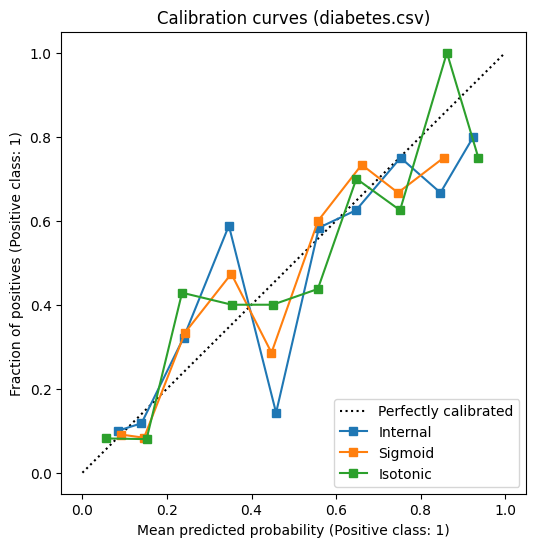

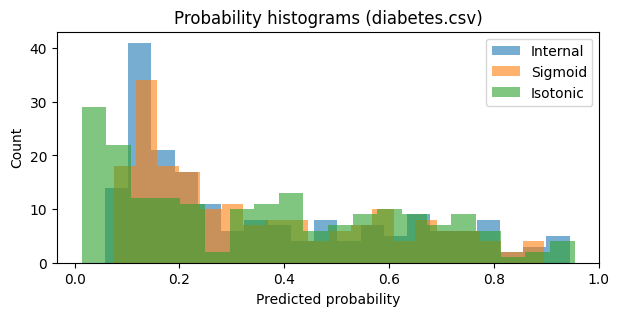

In [7]:
# Reliability diagrams (calibration plots)
fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(y_test, proba_test_internal, n_bins=10, name="Internal", ax=ax)
CalibrationDisplay.from_predictions(y_test, proba_sigmoid, n_bins=10, name="Sigmoid", ax=ax)
CalibrationDisplay.from_predictions(y_test, proba_isotonic, n_bins=10, name="Isotonic", ax=ax)
ax.set_title("Calibration curves (diabetes.csv)")
plt.show()

# Optional: histogram of predicted probabilities (to see confidence distribution)
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(proba_test_internal, bins=20, alpha=0.6, label="Internal")
ax.hist(proba_sigmoid, bins=20, alpha=0.6, label="Sigmoid")
ax.hist(proba_isotonic, bins=20, alpha=0.6, label="Isotonic")
ax.set_title("Probability histograms (diabetes.csv)")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Count")
ax.legend()
plt.show()

### چک‌لیست تفسیر (دودویی)

- منحنی **زیر** قطر: مدل **بیش‌ازحد مطمئن** است.
- منحنی **بالای** قطر: مدل **کم‌اعتماد** است.
- شکل S: نگاشت غیرخطی؛ isotonic ممکن است کمک کند.

و مقایسهٔ log loss و Brier را هم ببینید.

## 9) مطالعهٔ موردی B (چندکلاسه): iris.csv و glass.csv — کالیبراسیون چندکلاسه و شهود coupling

در چندکلاسه، ساخت احتمال پیچیده‌تر است.

### استراتژی‌های رایج

1. OvR
2. OvO و سپس pairwise coupling

`SVC(probability=True)` معمولاً OvO را اجرا می‌کند و سپس با coupling احتمال‌های نهایی را می‌سازد.

### شهود pairwise coupling

اگر $p_{ij}(x)$ احتمال کلاس $i$ در برابر $j$ باشد، می‌خواهیم $p_i(x)$ها طوری باشند که:
$$
p_{ij}(x) \approx \frac{p_i(x)}{p_i(x) + p_j(x)}.
$$

In [8]:
# Multiclass example: iris.csv
X, y = load_iris()
classes = np.sort(y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Uncalibrated (scores) via SVC(probability=False)
svm_mc = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=3.0, gamma="scale", probability=False, random_state=42))
])

# Internal probabilities (libsvm)
svm_mc_prob = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=3.0, gamma="scale", probability=True, random_state=42))
])

# External calibration using OvR-style calibration inside sklearn
svm_mc_base = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=3.0, gamma="scale", probability=False, random_state=42))
])

cal_mc_sigmoid = CalibratedClassifierCV(svm_mc_base, method="sigmoid", cv=5)
cal_mc_isotonic = CalibratedClassifierCV(svm_mc_base, method="isotonic", cv=5)

svm_mc.fit(X_train, y_train)
svm_mc_prob.fit(X_train, y_train)
cal_mc_sigmoid.fit(X_train, y_train)
cal_mc_isotonic.fit(X_train, y_train)

proba_internal = svm_mc_prob.predict_proba(X_test)
proba_sigmoid = cal_mc_sigmoid.predict_proba(X_test)
proba_isotonic = cal_mc_isotonic.predict_proba(X_test)

# Metrics: multiclass log loss and multiclass Brier
print("Multiclass log loss (internal):", log_loss(y_test, proba_internal, labels=classes))
print("Multiclass log loss (sigmoid): ", log_loss(y_test, proba_sigmoid, labels=classes))
print("Multiclass log loss (isotonic):", log_loss(y_test, proba_isotonic, labels=classes))

print("Multiclass Brier (internal):", brier_multiclass(proba_internal, y_test, classes))
print("Multiclass Brier (sigmoid): ", brier_multiclass(proba_sigmoid, y_test, classes))
print("Multiclass Brier (isotonic):", brier_multiclass(proba_isotonic, y_test, classes))

Multiclass log loss (internal): 0.1490926700901263
Multiclass log loss (sigmoid):  0.24784622834674339
Multiclass log loss (isotonic): 0.09350850562646863
Multiclass Brier (internal): 0.07534979358237877
Multiclass Brier (sigmoid):  0.10355633624327626
Multiclass Brier (isotonic): 0.05053404196949032


### نمایش کالیبراسیون چندکلاسه (ترفند عملی)

برای چندکلاسه یک منحنی واحد نداریم. یک روش عملی، بررسی «اطمینان top-1» است:

- $\hat{k}(x) = \arg\max_k \hat{p}_k(x)$
- $\hat{c}(x) = \max_k \hat{p}_k(x)$

سپس کالیبراسیون $\hat{c}(x)$ را به‌عنوان «احتمال درست‌بودن پیش‌بینی» بررسی می‌کنیم.

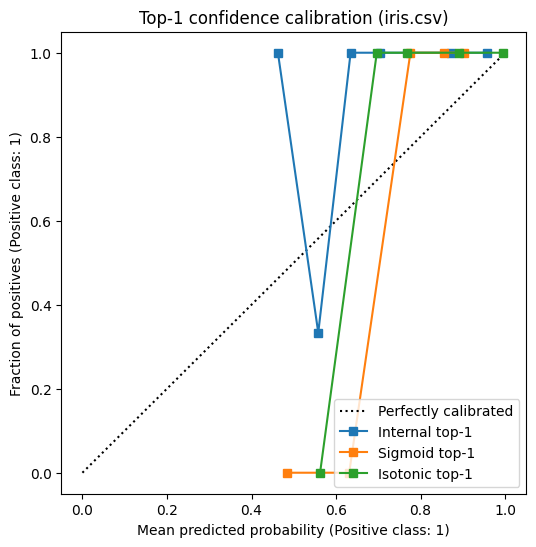

In [9]:
def top1_confidence_and_correct(y_true, proba, classes):
    classes = np.asarray(classes)
    y_true = np.asarray(y_true)
    pred_idx = np.argmax(proba, axis=1)
    pred_label = classes[pred_idx]
    conf = np.max(proba, axis=1)
    correct = (pred_label == y_true).astype(int)
    return conf, correct

conf_internal, corr_internal = top1_confidence_and_correct(y_test, proba_internal, classes)
conf_sigmoid, corr_sigmoid = top1_confidence_and_correct(y_test, proba_sigmoid, classes)
conf_isotonic, corr_isotonic = top1_confidence_and_correct(y_test, proba_isotonic, classes)

fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(corr_internal, conf_internal, n_bins=10, name="Internal top-1", ax=ax)
CalibrationDisplay.from_predictions(corr_sigmoid, conf_sigmoid, n_bins=10, name="Sigmoid top-1", ax=ax)
CalibrationDisplay.from_predictions(corr_isotonic, conf_isotonic, n_bins=10, name="Isotonic top-1", ax=ax)
ax.set_title("Top-1 confidence calibration (iris.csv)")
plt.show()

Glass multiclass log loss (internal): 0.6846077810970761
Glass multiclass log loss (sigmoid):  0.800571929037139
Glass multiclass log loss (isotonic): 0.5947162326345456


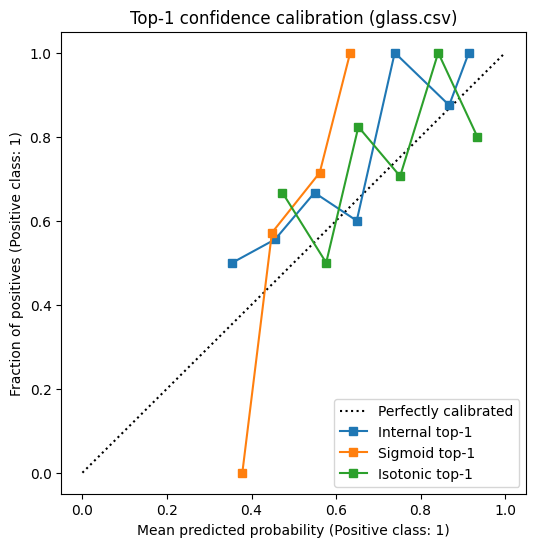

In [10]:
# Repeat quickly on glass.csv (multiclass, usually harder than iris)
X, y = load_glass()
classes = np.sort(y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=5.0, gamma="scale", probability=False, random_state=42))
])

cal_sigmoid = CalibratedClassifierCV(svm_base, method="sigmoid", cv=5)
cal_isotonic = CalibratedClassifierCV(svm_base, method="isotonic", cv=5)

svm_prob = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=5.0, gamma="scale", probability=True, random_state=42))
])

svm_prob.fit(X_train, y_train)
cal_sigmoid.fit(X_train, y_train)
cal_isotonic.fit(X_train, y_train)

p_internal = svm_prob.predict_proba(X_test)
p_sigmoid = cal_sigmoid.predict_proba(X_test)
p_isotonic = cal_isotonic.predict_proba(X_test)

print("Glass multiclass log loss (internal):", log_loss(y_test, p_internal, labels=classes))
print("Glass multiclass log loss (sigmoid): ", log_loss(y_test, p_sigmoid, labels=classes))
print("Glass multiclass log loss (isotonic):", log_loss(y_test, p_isotonic, labels=classes))

conf_i, corr_i = top1_confidence_and_correct(y_test, p_internal, classes)
conf_s, corr_s = top1_confidence_and_correct(y_test, p_sigmoid, classes)
conf_iso, corr_iso = top1_confidence_and_correct(y_test, p_isotonic, classes)

fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(corr_i, conf_i, n_bins=10, name="Internal top-1", ax=ax)
CalibrationDisplay.from_predictions(corr_s, conf_s, n_bins=10, name="Sigmoid top-1", ax=ax)
CalibrationDisplay.from_predictions(corr_iso, conf_iso, n_bins=10, name="Isotonic top-1", ax=ax)
ax.set_title("Top-1 confidence calibration (glass.csv)")
plt.show()

## 10) مطالعهٔ موردی C: drug200.csv — ویژگی‌های دسته‌ای، پایپلاین‌ها، و کالیبراسیون

برای دادهٔ ترکیبی:

- عددی: `StandardScaler`
- دسته‌ای: `OneHotEncoder`

در اینجا یک پایپلاین کامل می‌سازیم و سپس کالیبره می‌کنیم.

### نکتهٔ عملی

- `SVC(probability=True)` می‌تواند کند شود.
- `CalibratedClassifierCV` کنترل بیشتری می‌دهد و برای `LinearSVC` هم جواب می‌دهد.

Numeric columns: ['Age', 'Na_to_K']
Categorical columns: ['Sex', 'BP', 'Cholesterol']
Classes: ['DrugY' 'drugA' 'drugB' 'drugC' 'drugX']
Multiclass log loss (sigmoid):  0.4661141079092316
Multiclass log loss (isotonic): 0.1868206778304868


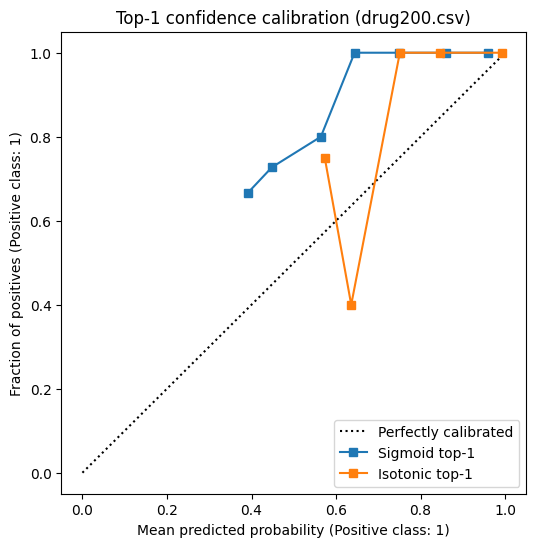

In [11]:
X, y = load_drug200()

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# We'll use a linear SVM for speed on one-hot features
linear_svm = LinearSVC(C=1.0, random_state=42)

# Calibrate LinearSVC (it doesn't have predict_proba)
cal_sigmoid = CalibratedClassifierCV(
    Pipeline([("prep", preprocess), ("svm", linear_svm)]),
    method="sigmoid", cv=5
)
cal_isotonic = CalibratedClassifierCV(
    Pipeline([("prep", preprocess), ("svm", linear_svm)]),
    method="isotonic", cv=5
)

cal_sigmoid.fit(X_train, y_train)
cal_isotonic.fit(X_train, y_train)

p_sigmoid = cal_sigmoid.predict_proba(X_test)
p_isotonic = cal_isotonic.predict_proba(X_test)

classes = cal_sigmoid.classes_
print("Classes:", classes)

print("Multiclass log loss (sigmoid): ", log_loss(y_test, p_sigmoid, labels=classes))
print("Multiclass log loss (isotonic):", log_loss(y_test, p_isotonic, labels=classes))

# Top-1 confidence calibration
conf_s, corr_s = top1_confidence_and_correct(y_test, p_sigmoid, classes)
conf_iso, corr_iso = top1_confidence_and_correct(y_test, p_isotonic, classes)

fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(corr_s, conf_s, n_bins=10, name="Sigmoid top-1", ax=ax)
CalibrationDisplay.from_predictions(corr_iso, conf_iso, n_bins=10, name="Isotonic top-1", ax=ax)
ax.set_title("Top-1 confidence calibration (drug200.csv)")
plt.show()

## 11) مطالعهٔ موردی D: Wine_Quality.csv — عدم‌توازن، آستانه، و تفسیر احتمال

وقتی کیفیت را دودویی می‌کنیم، کلاس مثبت معمولاً کم‌تعدادتر است و این هم روی مرز تصمیم و هم روی کالیبراسیون اثر می‌گذارد.

### تغییر prior و اصلاح احتمالات

اگر prior بین آموزش و بهره‌برداری عوض شود، posterior هم عوض می‌شود. تحت فرض ثابت‌بودن likelihoodها می‌توان با بیز نسبت‌های شانس را اصلاح کرد:
$$
\\frac{P_{\\text{deploy}}(Y=1\\mid x)}{P_{\\text{deploy}}(Y=0\\mid x)} =
\\frac{\\pi_{\\text{deploy}}}{1-\\pi_{\\text{deploy}}}
\\cdot
\\frac{1-\\pi_{\\text{train}}}{\\pi_{\\text{train}}}
\\cdot
\\frac{P_{\\text{train}}(Y=1\\mid x)}{P_{\\text{train}}(Y=0\\mid x)}.
$$

### آستانهٔ هزینه‌محور

اگر هزینه‌ها متفاوت باشند:
$$
t = \\frac{C_{01}}{C_{01} + C_{10}}.
$$
این به کالیبراسیون درست نیاز دارد.

Positive rate (quality >= 7): 0.21641486320947326

Wine (sigmoid)
  Accuracy: 0.8285714285714286
  Log loss: 0.3622261858095848
  Brier: 0.11635211375053081
  ECE: 0.028331999484095066

Wine (isotonic)
  Accuracy: 0.8375510204081633
  Log loss: 0.3605982294111687
  Brier: 0.11565703835718322
  ECE: 0.02837836839070467


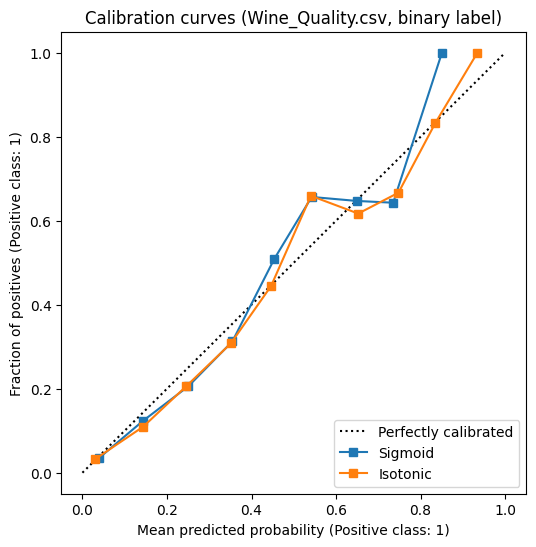

In [12]:
X, y = load_wine_quality_binary(threshold=7)

pos_rate = np.mean(y)
print("Positive rate (quality >= 7):", pos_rate)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Try class_weight='balanced' to account for imbalance
svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=3.0, gamma="scale", probability=False, class_weight="balanced", random_state=42))
])

cal_sigmoid = CalibratedClassifierCV(svm_base, method="sigmoid", cv=5)
cal_isotonic = CalibratedClassifierCV(svm_base, method="isotonic", cv=5)

cal_sigmoid.fit(X_train, y_train)
cal_isotonic.fit(X_train, y_train)

p_sigmoid = cal_sigmoid.predict_proba(X_test)[:, 1]
p_isotonic = cal_isotonic.predict_proba(X_test)[:, 1]

summarize_binary("Wine (sigmoid)", y_test, p_sigmoid)
summarize_binary("Wine (isotonic)", y_test, p_isotonic)

fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(y_test, p_sigmoid, n_bins=10, name="Sigmoid", ax=ax)
CalibrationDisplay.from_predictions(y_test, p_isotonic, n_bins=10, name="Isotonic", ax=ax)
ax.set_title("Calibration curves (Wine_Quality.csv, binary label)")
plt.show()

## 12) هایپرپارامترها و کالیبراسیون: چرا تنظیم برای accuracy می‌تواند احتمال‌ها را خراب کند

$C$ و $\gamma$ روی پیچیدگی مرز تصمیم اثر می‌گذارند. بیش‌برازش معمولاً به **بیش‌اعتمادی** منجر می‌شود.

اگر خروجی احتمال برای شما مهم است، بهتر است تنظیم را با **log loss** یا **Brier** انجام دهید، نه فقط accuracy.

Best params (accuracy): {'svm__C': 3.0, 'svm__gamma': 0.01}
Best params (log loss): {'estimator__svm__C': 1.0, 'estimator__svm__gamma': 0.1}

Tuned by accuracy, then calibrated
  Accuracy: 0.7239583333333334
  Log loss: 0.48959470887961704
  Brier: 0.16436977364203906
  ECE: 0.08093191176634584

Tuned directly for log loss (calibrated)
  Accuracy: 0.7395833333333334
  Log loss: 0.5096478384838878
  Brier: 0.1702507489948749
  ECE: 0.045880693402313676


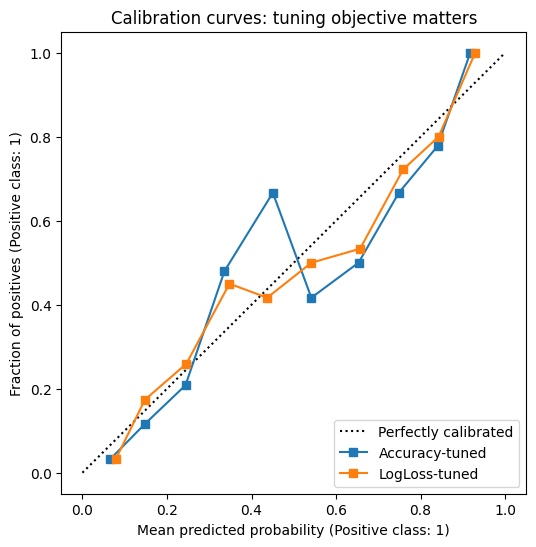

In [13]:
# Demonstration: tune an SVM by accuracy vs by log loss (on diabetes dataset)
# NOTE: scikit-learn changed the parameter name from base_estimator -> estimator in CalibratedClassifierCV.
# This cell is written to work across versions.

X, y = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=False, random_state=42))
])

param_grid = {
    "svm__C": [0.3, 1.0, 3.0, 10.0],
    "svm__gamma": ["scale", 0.01, 0.1, 1.0]
}

# Grid search for accuracy (does not require probabilities)
gs_acc = GridSearchCV(pipe, param_grid=param_grid, cv=5, scoring="accuracy")
gs_acc.fit(X_train, y_train)

# Grid search for log loss (requires probabilities).
# We tune a calibrated estimator (sigmoid/Platt) so that predict_proba exists for neg_log_loss scoring.
try:
    calibrated_est = CalibratedClassifierCV(estimator=pipe, method="sigmoid", cv=5)
    prefix = "estimator"
except TypeError:
    calibrated_est = CalibratedClassifierCV(base_estimator=pipe, method="sigmoid", cv=5)
    prefix = "base_estimator"

gs_logloss = GridSearchCV(
    calibrated_est,
    param_grid={
        f"{prefix}__svm__C": [0.3, 1.0, 3.0, 10.0],
        f"{prefix}__svm__gamma": ["scale", 0.01, 0.1, 1.0],
    },
    cv=3,
    scoring="neg_log_loss"
)
gs_logloss.fit(X_train, y_train)

print("Best params (accuracy):", gs_acc.best_params_)
print("Best params (log loss):", gs_logloss.best_params_)

# Evaluate on test set after calibrating each chosen model
def make_calibrator(est):
    try:
        return CalibratedClassifierCV(estimator=est, method="sigmoid", cv=5)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=est, method="sigmoid", cv=5)

best_acc_model = make_calibrator(gs_acc.best_estimator_)
best_acc_model.fit(X_train, y_train)
p_acc = best_acc_model.predict_proba(X_test)[:, 1]

best_ll_model = gs_logloss.best_estimator_
p_ll = best_ll_model.predict_proba(X_test)[:, 1]

summarize_binary("Tuned by accuracy, then calibrated", y_test, p_acc)
summarize_binary("Tuned directly for log loss (calibrated)", y_test, p_ll)

fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(y_test, p_acc, n_bins=10, name="Accuracy-tuned", ax=ax)
CalibrationDisplay.from_predictions(y_test, p_ll, n_bins=10, name="LogLoss-tuned", ax=ax)
ax.set_title("Calibration curves: tuning objective matters")
plt.show()

## 13) تعمق ریاضی: proper scoring rules و چرایی «یادگرفتنی بودن» کالیبراسیون

Log loss و Brier معیارهای proper هستند و با احتمال‌های واقعی کمینه می‌شوند؛ به همین دلیل یادگیری یک نگاشت کالیبراسیون معنی‌دار است.

همچنین معمولاً رابطهٔ مارجین و احتمال یکنواخت است، پس نگاشت‌های یکنواخت (sigmoid/isotonic) منطقی‌اند.

## 14) دام‌های عملی و بهترین رویه‌ها (چک‌لیست)

- روی test کالیبره نکنید (نشت داده).
- تنظیم و ارزیابی را جدا کنید (Nested CV برای گزارش صادقانه).
- isotonic با دادهٔ کم بیش‌برازش می‌کند.
- عدم‌توازن و آستانهٔ هزینه‌محور را در نظر بگیرید.
- تحت تغییر توزیع، کالیبراسیون می‌تواند خراب شود؛ پایش و بازکالیبراسیون لازم است.

## 15) تمرین‌ها (پیشنهادی)

1. کرنل‌های مختلف را روی `diabetes.csv` مقایسه کنید و log loss را بسنجید.
2. ECE را با تعداد bin متفاوت حساب کنید.
3. تغییر prior را شبیه‌سازی کنید و اثر آن روی کالیبراسیون را ببینید.
4. برای مسئلهٔ wine، آستانهٔ بهینهٔ هزینه‌محور را حساب کنید.
5. Nested CV را پیاده‌سازی کنید و میانگین/انحراف معیار log loss را گزارش دهید.

## منابع برای مطالعهٔ بیشتر

- Platt, J. (1999). *Probabilistic Outputs for Support Vector Machines and Comparisons to Regularized Likelihood Methods.*
- Zadrozny, B., & Elkan, C. (2002). *Transforming classifier scores into accurate multiclass probability estimates.*
- Niculescu-Mizil, A., & Caruana, R. (2005). *Predicting good probabilities with supervised learning.*
- مستندات scikit-learn دربارهٔ Calibration (`CalibratedClassifierCV`, `CalibrationDisplay`).